# PLOTTING IN PYTHON

## Introductory remarks

Why plotting?
- for ex**plor**ation (understanding the data using visualization, for ourselves)
- for ex**plan**ation (present information to others visually, for others)

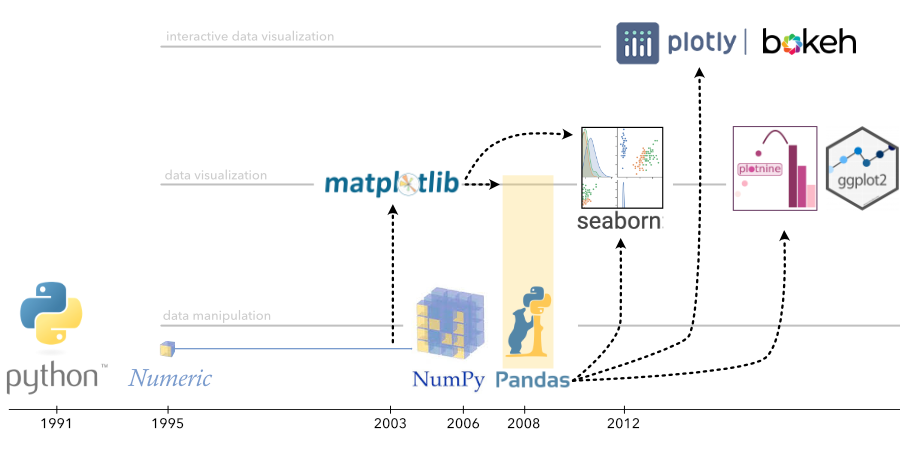

Characteristics of plotting with matplotlib, pandas, and seaborn:
- matplotlib: flexible with a lot of possibilities of customizations
- pandas: easy possibilities to visualize your data
- seaborn: easy to use with good-looking prepared designs  

All three libraries "cooperate", i.e. you can for example create a figure with pandas and adjust it with matplotlib lateron.

Which "dimensions" are available for plotting figures?
- absissa
- ordinate
- spatial figures
- 2nd ordinate / parameters (legend)
- different colors
- several plots side by side
- several plots in time sequence (animation) 


In [5]:
import pandas as pd

In [6]:
df = pd.read_csv('./penguins_simple.csv', sep=';')  # change path according to your local copy of the data

In [9]:
df.head()

,Species,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,Adelie,39.1,18.7,181.0,3750.0,MALE
1,Adelie,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,36.7,19.3,193.0,3450.0,FEMALE
4,Adelie,39.3,20.6,190.0,3650.0,MALE


## 1. Plotting with pandas

<AxesSubplot:>

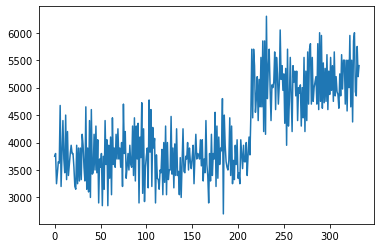

In [11]:
# plot one column

df['Body Mass (g)'].plot()   # default: line-plot.

<AxesSubplot:>

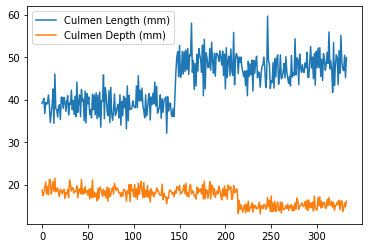

In [15]:
# plot two columns
df[['Culmen Length (mm)', 'Culmen Depth (mm)']].plot()  # legend inserted automatically

#### Let's try to answer following questions (using figures)
1. Do heavy penguins have longer flippers?  

<AxesSubplot:xlabel='Body Mass (g)', ylabel='Flipper Length (mm)'>

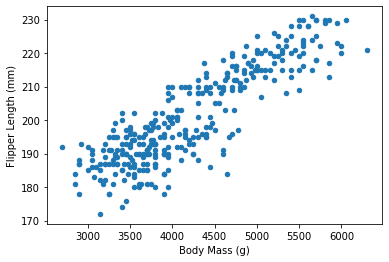

In [17]:
# plot one column against another
df.plot(x='Body Mass (g)', y='Flipper Length (mm)', kind='scatter')  # second kind of syntax

BTW: seaborn (see below) also allows to directly add a regression line: `sns.lmplot(...)`

2. Visualize the distribution of Culmen Length

In [ ]:
# we have multiple options: hist, kde, boxplot
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html

<AxesSubplot:ylabel='Frequency'>

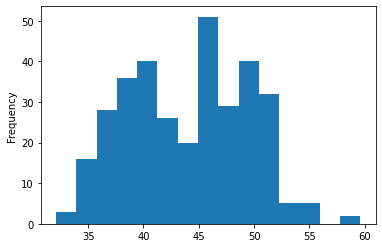

In [23]:
df['Culmen Length (mm)'].plot(kind='hist', bins=15)

<AxesSubplot:>

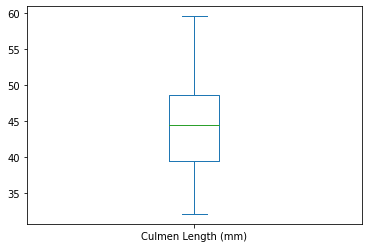

In [24]:
df['Culmen Length (mm)'].plot(kind='box')

In [ ]:
# green line: median (splits the samples into equal-numbered halfs)
# box: Interquartile range (50% in the middle)
# whiskers: highest and lowest occuring value in Q1 − 1.5*IQR and Q3 + 1.5*IQR
# plus maybe outliers

3. Are male penguins heavier than female penguins?

<AxesSubplot:ylabel='Frequency'>

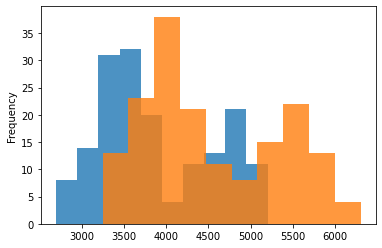

In [33]:
# selecting by conditions, plotting two in one, introducing alpha, histogram
df['Body Mass (g)'].loc[df['Sex'] == 'FEMALE'].plot(alpha = 0.8, kind='hist')  # legend will only display column-name
df['Body Mass (g)'].loc[df['Sex'] == 'MALE'].plot(alpha = 0.8, kind='hist')

In [ ]:
# here we now see: maybe we want to adjust some things, customizer, add a legend,... 
# for this, we need to look a bit deeper --> matplotlib

#### Other plots with pandas: 
check the documentation [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html).

## 2. Plotting with Matplotlib

In [34]:
import matplotlib.pyplot as plt

In [35]:
# Build the next plot up gradually:

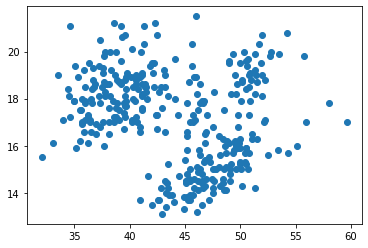

In [38]:
plt.scatter(df['Culmen Length (mm)'], df['Culmen Depth (mm)'])  

plt.show()  # good idea to add at the end. IDEs often require this.

# or: plt.plot, plt.bar, plt.boxplot, plt.hist,... 

# really "raw", no labels, ...

#### Add title and labels

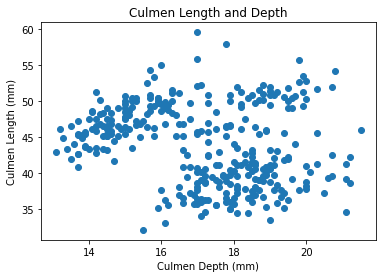

In [39]:
plt.scatter(df['Culmen Depth (mm)'], df['Culmen Length (mm)']) 
plt.title('Culmen Length and Depth')
plt.xlabel('Culmen Depth (mm)')
plt.ylabel('Culmen Length (mm)')
plt.show()

# also possible: plt.set_xticks, set_xticklabels,
# Google one option, e.g. : how to rotate ticks (matplotlib rotate ticks, stackoverflow or matplotlib documentation)

#### More formatting

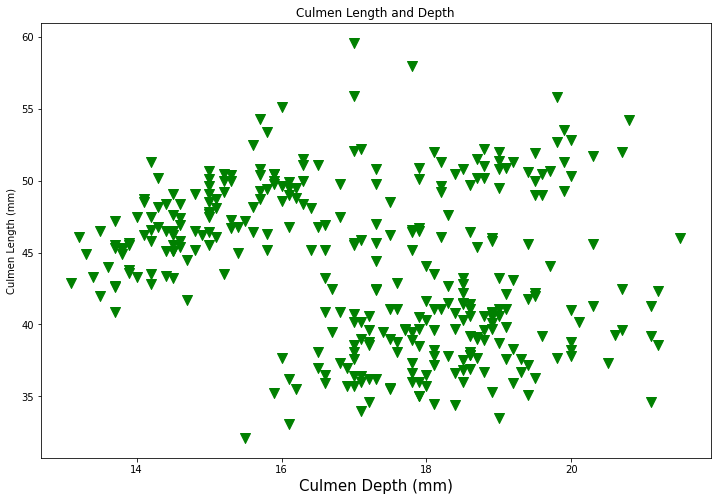

In [43]:
# formatting "datapoints", add s, c, marker
plt.figure(figsize=(12,8))  # order! First step before plot is drawn
plt.scatter(df['Culmen Depth (mm)'], df['Culmen Length (mm)'], s=100, c='green', marker='v') 
# look in the doc here what we can change.
plt.title('Culmen Length and Depth')
plt.xlabel('Culmen Depth (mm)', fontsize=15)
plt.ylabel('Culmen Length (mm)')
plt.show()

# available parameters depend on the kind of plot, e.g. linewidth,...

In [ ]:
# some formatting options: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

Look [here](https://matplotlib.org/3.5.0/gallery/showcase/anatomy.html) for the "anatomy of plotting".

### Multiple plots in one

In [ ]:
# Just add another plot! But be aware of the axes.  Can also contain different kinds of plots.

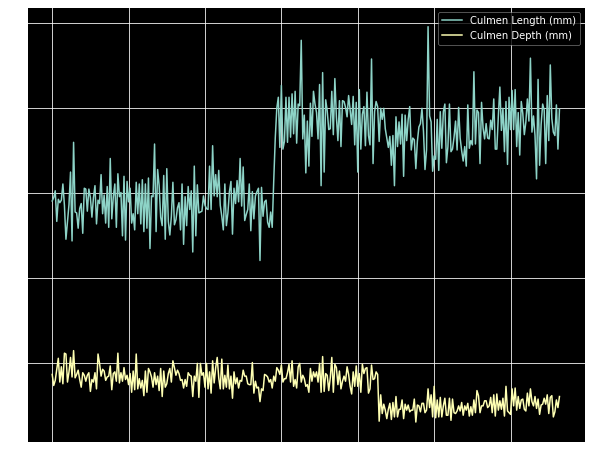

In [47]:
# first: multiple plots. then: add legend, add style. 
plt.figure(figsize=(10,8))

plt.style.use('dark_background')


plt.plot(df['Culmen Length (mm)'], label='Culmen Length (mm)')

plt.plot(df['Culmen Depth (mm)'], label='Culmen Depth (mm)')

plt.legend() # can also give list of labels here, in order.

plt.show()
# defaults for colors, grid, labels, etc -> can be overwritten though.

In [48]:
plt.style.available
# https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn',
 'seaborn-bright',
 'seaborn-colorblind',
 'seaborn-dark',
 'seaborn-dark-palette',
 'seaborn-darkgrid',
 'seaborn-deep',
 'seaborn-muted',
 'seaborn-notebook',
 'seaborn-paper',
 'seaborn-pastel',
 'seaborn-poster',
 'seaborn-talk',
 'seaborn-ticks',
 'seaborn-white',
 'seaborn-whitegrid',
 'tableau-colorblind10']

### Saving plots

In [49]:
plt.savefig('plot.png')  # put in same cell as plot.

<Figure size 432x288 with 0 Axes>

In [51]:
ls -l plot.png

-rw-rw-r-- 1 thomas thomas 1258 Mai 10 10:21 plot.png


Gallery: https://matplotlib.org/stable/gallery/index.html  
There are also a lot of nice youtube videos on matplotlib.

## 3. Plotting with Seaborn

In [ ]:
#!conda install seaborn

#!conda install -c conda-forge seaborn

#!pip install seaborn

In [52]:
import seaborn as sns  # sns stands for "seaborn name space" (?)

Text(0.5, 1.0, 'Culmen Lenght and depth by Species')

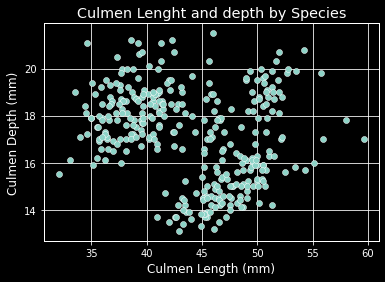

In [53]:
sns.scatterplot(data=df, x='Culmen Length (mm)', y='Culmen Depth (mm)')
plt.title('Culmen Lenght and depth by Species')  # cooperates with matplotlib

#### Alter the look

There are several [color palettes](https://seaborn.pydata.org/tutorial/color_palettes.html) and [styles](https://seaborn.pydata.org/tutorial/aesthetics.html) available. Set them before plotting.

In [54]:
sns.set_palette(sns.color_palette('Set2'))
sns.set_style("white")

<AxesSubplot:xlabel='Body Mass (g)', ylabel='Count'>

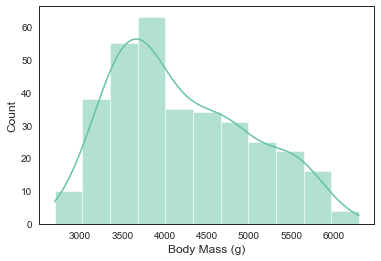

In [56]:
sns.histplot(df['Body Mass (g)'], kde=True)

#### pairplots and heatmaps

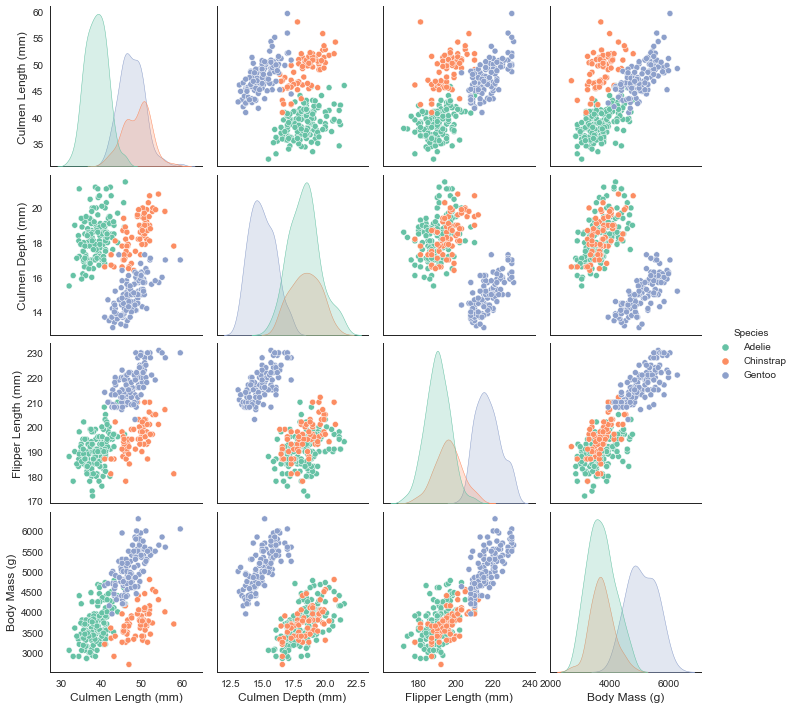

In [59]:
sns.pairplot(data=df, hue='Species')

In [60]:
df.corr()

,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
Culmen Length (mm),1.000000,-0.228626,0.653096,0.589451
Culmen Depth (mm),-0.228626,1.000000,-0.577792,-0.472016
Flipper Length (mm),0.653096,-0.577792,1.000000,0.872979
Body Mass (g),0.589451,-0.472016,0.872979,1.000000


<AxesSubplot:>

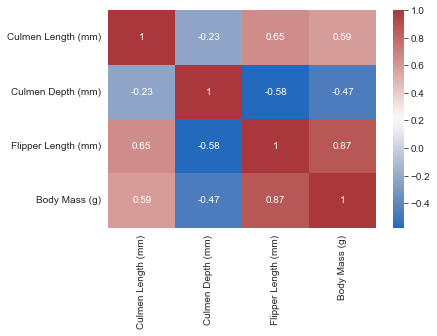

In [63]:
sns.heatmap(df.corr(), cmap='vlag', annot=True)

#### Exercises with seaborn and matplotlib: 
- Draw a histogram that shows how many penguins of each species are in the data
- create a plot of your choosing that only shows the data of female Gentoos.
- Create a scatterplot of the culmen length and depth where the size of the markers represent the Body mass of the penguin
- Find at least one more way (besides a scatterplot) to visualize the relationship between culmen lenght and depth (or another bivariate distribution)

**Try to find the solutions _before_ you cheat here:**

In [ ]:
# 1. sns.histplot(df['Species'])
# 2. sns.scatterplot(data=df[(df['Species'] == 'Adelie') & (df['Sex'] == 'FEMALE')], x='Culmen Length (mm)', y='Culmen Depth (mm)')
# 3. sns.scatterplot(data=df, x='Culmen Length (mm)', y='Culmen Depth (mm)', size='Body Mass (g)')
# 4. sns.displot(df, x='Culmen Length (mm)', y='Culmen Depth (mm)')

## More advanced plotting

#### Subplots
In matplotlib, the "figure" is like a container that holds plots (called "axes"). 
You can create a grid of plots, e.g. with two plots in one figure like this: 


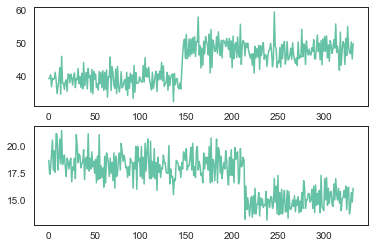

In [64]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1) 
ax1.plot(df['Culmen Length (mm)'])   # specifies first plot
ax2.plot(df['Culmen Depth (mm)'])     # specifies second plot

#### 3D plots

<IPython.core.display.Javascript object>


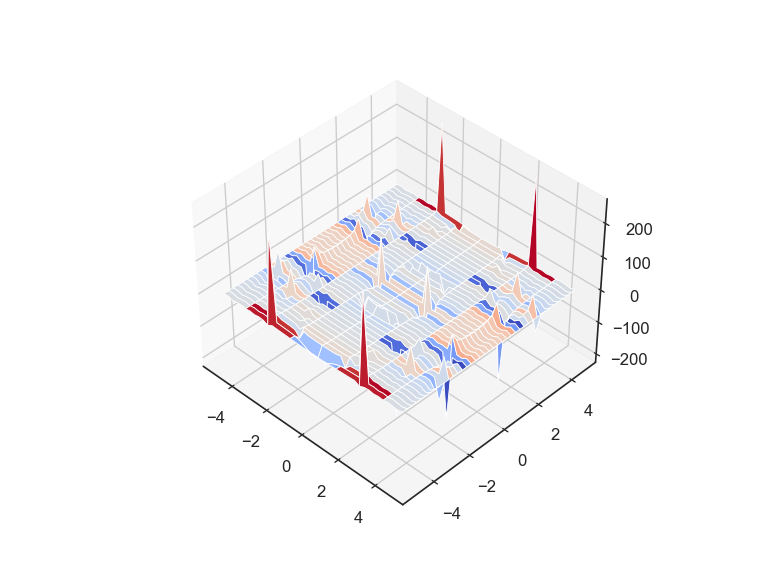

In [67]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
X = np.arange(-5, 5, 0.25)
Y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(X, Y)
R = np.sqrt(X**4 + Y**2)
Z = np.tan(R)
surf = ax.plot_surface(X, Y, Z, rstride=1, cstride=5, cmap=cm.coolwarm)
plt.show()

In [68]:
# You can also make the plot rotatable:
# add at the beginning of the previous cell:
#%matplotlib notebook

# and in the following cell:
%matplotlib inline
plt.close(fig)

## Outlook

### Other plotting packages / tutorials /etc.
- [plotly](https://plotly.com/)
- [bokeh](https://docs.bokeh.org/en/latest/)


- [Tutorial on matplotlib](https://matplotlib.org/stable/tutorials/introductory/pyplot.html#sphx-glr-tutorials-introductory-pyplot-py)
- [another one](https://pynative.com/python-matplotlib-exercise/)
- [matplotlib exercises](https://www.geeksforgeeks.org/matplotlib-practice-exercise-and-solutions/)
- [Tutorial on seaborn](https://seaborn.pydata.org/tutorial.html)
- [Plotting ideas and their implementation](https://www.python-graph-gallery.com/)


- Advices on how to use colors ([[1](https://academy.datawrapper.de/article/140-what-to-consider-when-choosing-colors-for-data-visualization)] and [[2](https://projects.susielu.com/viz-palette)])


## To do now

- [work on the milestones](https://spiced.space/poisson-ivy/ds-course/chapters/project_gapminder/README.html)  
- **optional!!** have a look at the bonus(!) goals (scattered througout the course material)